# SmartHandover — Day 1: VADER Baseline

Corre o classificador VADER (léxico) sobre o dataset MELD e calcula métricas de avaliação.

**Toggle:** muda `USE_MOCK = True` na célula de config para usar dados dummy (sem download).

In [1]:
# Instalar dependencias no kernel ativo (correr 1x)
%pip install vaderSentiment pandas scikit-learn tqdm matplotlib datasets librosa soundfile torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
# === CONFIG ===
USE_MOCK = False  # True = dados dummy, False = MELD real

In [3]:
import os, sys
import pandas as pd
from tqdm.notebook import tqdm

# Garantir que o project root esta no path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [4]:
from src.classifiers.vader_classifier import VaderClassifier

TARGET_LABELS = ["anger", "frustration", "sadness", "neutral", "satisfaction"]
TARGET_LABEL2ID = {label: i for i, label in enumerate(TARGET_LABELS)}

## 1. Carregar dados

In [5]:
def create_mock_data():
    samples = [
        ("I am so angry at you right now!", "anger"),
        ("This is absolutely unacceptable, I'm furious!", "anger"),
        ("You ruined everything, I hate this!", "anger"),
        ("Stop doing that, it's driving me crazy!", "anger"),
        ("I can't believe you did that, I'm livid!", "anger"),
        ("This is so frustrating, nothing works.", "frustration"),
        ("I've been waiting for an hour, this is ridiculous.", "frustration"),
        ("Why does this keep happening to me?", "frustration"),
        ("I'm so tired of dealing with this problem.", "frustration"),
        ("Every time I try, something goes wrong.", "frustration"),
        ("I feel so sad and lonely today.", "sadness"),
        ("It breaks my heart to see this.", "sadness"),
        ("I miss the way things used to be.", "sadness"),
        ("Nothing seems to matter anymore.", "sadness"),
        ("I just want to cry.", "sadness"),
        ("The meeting is at 3pm.", "neutral"),
        ("I'll check and get back to you.", "neutral"),
        ("Sure, that works for me.", "neutral"),
        ("Let me know when you're ready.", "neutral"),
        ("The report is on the shared drive.", "neutral"),
        ("Okay.", "neutral"),
        ("I see.", "neutral"),
        ("That's fine.", "neutral"),
        ("This is wonderful, I'm so happy!", "satisfaction"),
        ("Great job, I really appreciate your help!", "satisfaction"),
        ("Everything worked out perfectly!", "satisfaction"),
        ("I'm really pleased with the results.", "satisfaction"),
        ("Thank you so much, this is amazing!", "satisfaction"),
    ]
    return pd.DataFrame(samples, columns=["text", "target_emotion"])


def load_meld_as_dataframe():
    from src.data.load_meld import load_meld
    rows = []
    for split in ["train", "validation", "test"]:
        print(f"  Loading MELD split: {split} ...")
        ds = load_meld(split=split, streaming=False)
        for example in ds:
            rows.append({
                "text": example["text"],
                "target_emotion": example["target_emotion"],
                "split": split,
            })
    return pd.DataFrame(rows)


if USE_MOCK:
    print("[INFO] A usar dados MOCK.")
    df = create_mock_data()
else:
    print("[INFO] A carregar MELD real do HuggingFace...")
    try:
        df = load_meld_as_dataframe()
    except Exception as e:
        print(f"[WARN] Falha ao carregar MELD: {e}\n[WARN] Fallback para mock data.")
        df = create_mock_data()

print(f"\nTotal amostras: {len(df)}")
df["target_emotion"].value_counts()

[INFO] A carregar MELD real do HuggingFace...
  Loading MELD split: train ...
  Loading MELD split: validation ...
  Loading MELD split: test ...

Total amostras: 12070


target_emotion
neutral         6434
satisfaction    2308
anger           1968
sadness         1002
frustration      358
Name: count, dtype: int64

## 2. Correr VADER sobre todas as amostras

In [6]:
classifier = VaderClassifier()

predictions = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="VADER"):
    result = classifier.predict_and_classify(row["text"])
    predictions.append({
        "text": row["text"],
        "true_label": row["target_emotion"],
        "predicted_class": result["predicted_class"],
        "vader_pos": result["pos"],
        "vader_neg": result["neg"],
        "vader_neu": result["neu"],
        "vader_compound": result["compound"],
    })

results_df = pd.DataFrame(predictions)
results_df.head(10)

VADER:   0%|          | 0/12070 [00:00<?, ?it/s]

,text,true_label,predicted_class,vader_pos,vader_neg,vader_neu,vader_compound
0,also I was the point person on my companys tr...,neutral,neutral,0.000,0.000,1.000,0.0000
1,You mustve had your hands full.,neutral,neutral,0.000,0.000,1.000,0.0000
2,No dont I beg of you!,frustration,anger,0.000,0.333,0.667,-0.3595
3,"All right then, well have a definite answer f...",neutral,satisfaction,0.351,0.000,0.649,0.8979
4,Absolutely. You can relax,neutral,satisfaction,0.513,0.000,0.487,0.4877
5,That I did. That I did.,neutral,neutral,0.000,0.000,1.000,0.0000
6,So lets talk a little bit about your duties.,neutral,neutral,0.000,0.000,1.000,0.0000
7,"Now youll be heading a whole division, so you...",neutral,neutral,0.000,0.000,1.000,0.0000
8,I see.,neutral,neutral,0.000,0.000,1.000,0.0000
9,But therell be perhaps 30 people under you so...,neutral,sadness,0.124,0.177,0.699,-0.2836


## 3. Guardar predicoes em CSV

In [7]:
output_path = os.path.join("..", "data", "processed", "vader_predictions.csv")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
results_df.to_csv(output_path, index=False)
print(f"Guardado em: {output_path}")

Guardado em: ..\data\processed\vader_predictions.csv


## 4. Metricas de avaliacao

In [8]:
from src.evaluation.metrics import compute_metrics, print_metrics

y_true = [TARGET_LABEL2ID[label] for label in results_df["true_label"]]
y_pred = [TARGET_LABEL2ID[label] for label in results_df["predicted_class"]]

metrics = compute_metrics(y_true, y_pred, target_names=TARGET_LABELS)
print_metrics(metrics)


  Accuracy     : 0.5015
  Weighted F1  : 0.4795
  Macro F1     : 0.2962
  Frustration R: 0.0000  << KEY METRIC

  Class             Prec    Rec     F1  Support
  -------------------------------------------
  anger            0.377  0.194  0.256     1968
  frustration      0.000  0.000  0.000      358 <<
  sadness          0.241  0.147  0.182     1002
  neutral          0.621  0.688  0.653     6434
  satisfaction     0.330  0.475  0.390     2308

  Confusion Matrix (rows=true, cols=pred):
            anger  frust  sadne  neutr  satis
    anger     381      0    101   1010    476
    frust      65      0     30    189     74
    sadne     192      0    147    453    210
    neutr     261      0    280   4428   1465
    satis     111      0     53   1047   1097


## 5. Distribuicao dos scores VADER por classe real

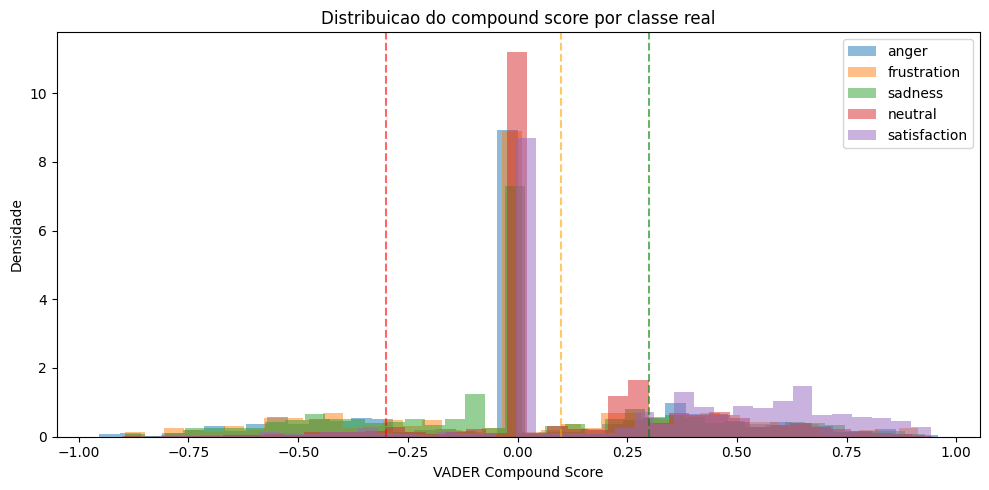

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for label in TARGET_LABELS:
    subset = results_df[results_df["true_label"] == label]["vader_compound"]
    ax.hist(subset, bins=40, alpha=0.5, label=label, density=True)

ax.set_xlabel("VADER Compound Score")
ax.set_ylabel("Densidade")
ax.set_title("Distribuicao do compound score por classe real")
ax.legend()
ax.axvline(x=-0.3, color="red", linestyle="--", alpha=0.6)
ax.axvline(x=0.1, color="orange", linestyle="--", alpha=0.6)
ax.axvline(x=0.3, color="green", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()